In [26]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
PKLs = []
PKL_titles = []
for file in os.listdir("./"):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(file, "rb")))
        PKL_titles.append(str(file))

In [27]:
PKLs[0].keys()

dict_keys(['title', 'config', 'acceptance_rate', 'info', 'esjd', 'logZ_logW', 'lmbda', 'paths'])

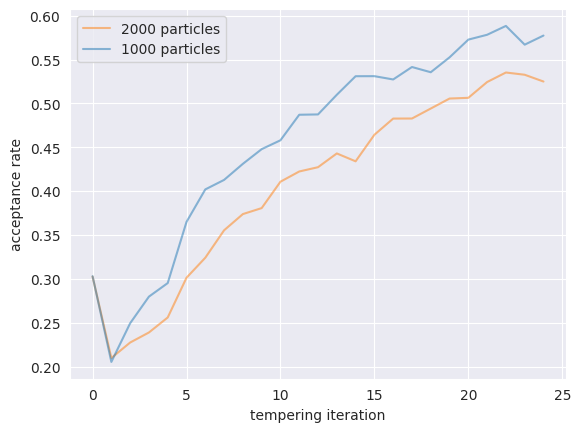

In [28]:
N = np.array([1000, 2000])
palette = sns.color_palette(None, len(N))
palette_dict = dict(zip(N, palette))

for idx, pkl in enumerate(PKLs):
    num_particles = pkl['config']['num_particles']
    plt.plot(pkl['acceptance_rate'].mean(axis=-1), alpha=0.5, label=f'{num_particles} particles',  c=palette_dict[num_particles])
plt.ylabel("acceptance rate")
plt.xlabel("tempering iteration")
plt.legend()

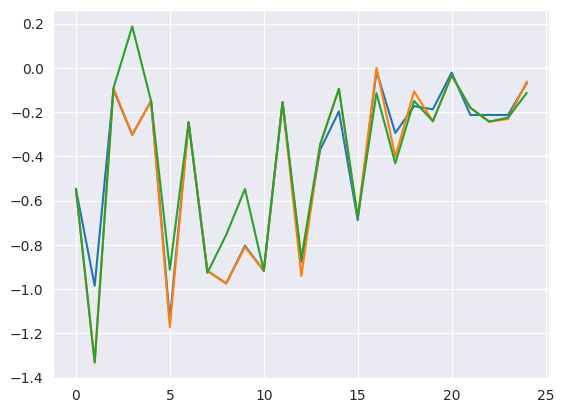

In [29]:
plt.plot(pkl['info'].update_info.proposal.position[0][0,...,0][:,0,:])

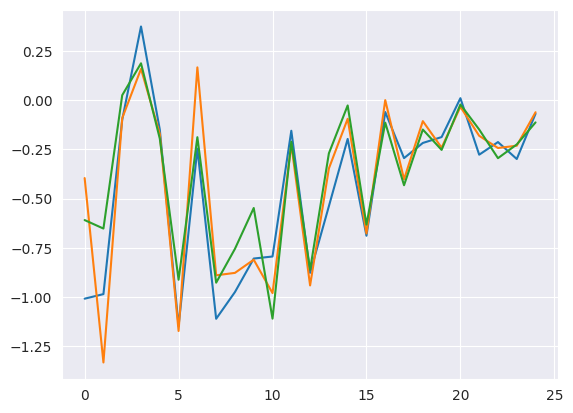

In [30]:
plt.plot(pkl['info'].update_info.proposed_states.position[0][0,...,0][:,0,:])

In [ ]:
N = np.array([60, 100, 200, 500, 1000])
period_max = np.array([1, 2, 3])
palette = sns.color_palette(None, len(N))
palette_dict = dict(zip(N, palette))
linstyles = ['dotted', 'dashdot', 'dashed', 'solid']
linstyles_dict = dict(zip(period_max, linstyles))

for idx, pkl in enumerate(PKLs):
    if "wf" not in PKL_titles[idx]:
        num_particles = pkl['config']['num_particles']
        period_max = pkl['config']['params_proposal'][1]
        if period_max == 1:
            plt.plot(pkl['acceptance_rate'].mean(axis=-1), alpha=0.5, linestyle=linstyles_dict[period_max], c=palette_dict[num_particles])
        else:
            plt.plot(pkl['acceptance_rate'].mean(axis=-1), label=(f'{num_particles}'), linestyle=linstyles_dict[period_max], alpha=0.5, c=palette_dict[num_particles])
plt.legend()

In [35]:
pkl['info'].__dir__()

['__doc__',
 '__slots__',
 '_fields',
 '_field_defaults',
 '__new__',
 '_make',
 '_replace',
 '__repr__',
 '_asdict',
 '__getnewargs__',
 '__match_args__',
 'ancestors',
 'log_likelihood_increment',
 'update_info',
 '__module__',
 '__annotations__',
 '__orig_bases__',
 '__hash__',
 '__getattribute__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__iter__',
 '__len__',
 '__getitem__',
 '__add__',
 '__mul__',
 '__rmul__',
 '__contains__',
 'index',
 'count',
 '__class_getitem__',
 '__str__',
 '__setattr__',
 '__delattr__',
 '__init__',
 '__reduce_ex__',
 '__reduce__',
 '__getstate__',
 '__subclasshook__',
 '__init_subclass__',
 '__format__',
 '__sizeof__',
 '__dir__',
 '__class__']

In [157]:
def get_pair(m, p, t):
    _, T, M, P, _ = pkl['info'].update_info.proposed_states.position[0].shape
    assert t<T
    assert m<M
    assert p<=P
    proposed_states = pkl['info'].update_info.proposed_states.position[0]
    proposal_states = pkl['info'].update_info.proposal.position[0]
    ancestors = pkl['info'].ancestors
    if p >= 1:
        barXtmp = proposed_states[:,t, m, p]
        tildeXtmpm1 = proposal_states[:,t,m,p-1]
    if p==0:
        barXtmp = proposed_states[:,t, m, p]
        ancestor_particle_index_m = ancestors[:,t,m] % M
        ancestor_particle_index_p = ancestors[:,t,m] // M
        proposal_states_slice = proposal_states[:,t-1,...]
        tildeXtmpm1 = [proposal_states_slice[*triple] for triple in zip(np.arange(0, proposal_states.shape[0]), ancestor_particle_index_m, ancestor_particle_index_p)]
    return barXtmp, tildeXtmpm1
    

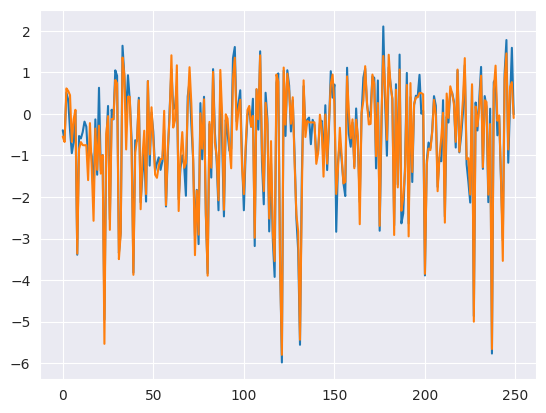

In [171]:
plt.plot([get_pair(m, 1, 0)[0][0,0] for m in range(250)])
plt.plot([get_pair(m, 1, 0)[1][0,0] for m in range(250)])

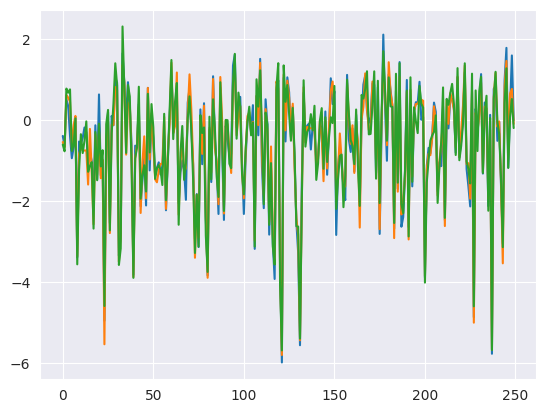

In [189]:
plt.plot([get_pair(m, 1, 0)[0][0][0] for m in range(250)])
plt.plot([get_pair(m, 1, 0)[1][0][0] for m in range(250)])
plt.plot([get_pair(m, 2, 0)[0][0][0] for m in range(250)])

In [174]:
proposal_states = pkl['info'].update_info.proposal.position[0]


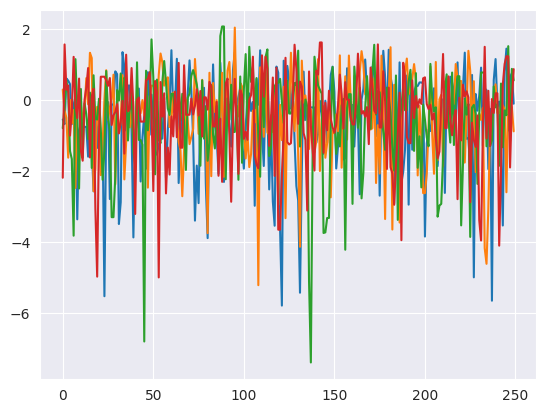

In [183]:
plt.plot(proposal_states[:,0,...,0,0].T)

In [186]:
proposal_states[:,-1]

Array([[[[-0.06907548, -0.4048974 ,  0.05083792, ..., -0.18515658,
           0.36064067, -0.99043316],
         [-0.06168369, -0.39307737,  0.06980128, ..., -0.07877484,
           0.33401433, -0.99330115],
         [-0.11329637, -0.39305598,  0.0161531 , ..., -0.27102494,
           0.3160895 , -0.97584975]],

        [[-0.18396857, -0.33878553, -0.07129061, ..., -0.36958003,
           0.27696434, -0.62541085],
         [-0.12564373, -0.275402  , -0.22394702, ..., -0.23175982,
           0.21428135, -0.62848526],
         [-0.12564373, -0.275402  , -0.22394702, ..., -0.23175982,
           0.21428135, -0.62848526]],

        [[-0.11110377, -0.38857833, -0.03785956, ..., -0.52917486,
           0.67271924, -0.914647  ],
         [-0.11110377, -0.38857833, -0.03785956, ..., -0.52917486,
           0.67271924, -0.914647  ],
         [-0.13666248, -0.33812442, -0.0442529 , ..., -0.43065   ,
           0.6880101 , -0.91424805]],

        ...,

        [[-0.15947355, -0.8737319 ,  0.52674

In [187]:
proposal_states[:,25]

Array([[[[-0.06907548, -0.4048974 ,  0.05083792, ..., -0.18515658,
           0.36064067, -0.99043316],
         [-0.06168369, -0.39307737,  0.06980128, ..., -0.07877484,
           0.33401433, -0.99330115],
         [-0.11329637, -0.39305598,  0.0161531 , ..., -0.27102494,
           0.3160895 , -0.97584975]],

        [[-0.18396857, -0.33878553, -0.07129061, ..., -0.36958003,
           0.27696434, -0.62541085],
         [-0.12564373, -0.275402  , -0.22394702, ..., -0.23175982,
           0.21428135, -0.62848526],
         [-0.12564373, -0.275402  , -0.22394702, ..., -0.23175982,
           0.21428135, -0.62848526]],

        [[-0.11110377, -0.38857833, -0.03785956, ..., -0.52917486,
           0.67271924, -0.914647  ],
         [-0.11110377, -0.38857833, -0.03785956, ..., -0.52917486,
           0.67271924, -0.914647  ],
         [-0.13666248, -0.33812442, -0.0442529 , ..., -0.43065   ,
           0.6880101 , -0.91424805]],

        ...,

        [[-0.15947355, -0.8737319 ,  0.52674